# Notebook 02: Activation Patching & Circuit Verification

**Goal:** Verify the causal role of induction heads.

**Outputs:** `experiments/results/baseline_attribution_scores.npz`, `paper/figures/fig1_*`, `paper/figures/fig4_*`

**Runtime:** ~15 minutes on CPU.

In [ ]:
import os
import sys
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path

# Define repository information
repo_name = "Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_url = "https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_path = f"/content/{repo_name}" # Standard Colab clone location

# Clone the repository if it doesn't exist
if not os.path.exists(repo_path):
    print(f"Cloning {repo_url} to {repo_path}...")
    !git clone {repo_url} {repo_path}

# Change current working directory to the repository root
# This allows relative imports (like 'src.model...') to work correctly
if os.getcwd() != repo_path:
    print(f"Changing current directory to {repo_path}")
    os.chdir(repo_path)

# Add the current directory (repo root) to sys.path if not already there
# This ensures 'src' is discoverable for imports.
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Install project dependencies from requirements.txt
# This ensures all necessary libraries, including transformer_lens and transformers,
# are installed with the versions specified by the project.
print(f"Installing dependencies from {repo_path}/requirements.txt...")
!pip install -r requirements.txt

# Original imports
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.patching import compute_circuit_attribution, get_circuit_heads
from src.viz.circuit_diagram import plot_circuit_diagram, plot_attribution_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Please restart the Colab runtime after executing the cell above.

Go to `Runtime` -> `Restart runtime...` or press `Ctrl + M` then `.` (Cmd + M then . on Mac) and confirm the restart. This ensures that all newly installed packages, especially core ones like `torch` and `transformers`, are correctly loaded into the environment.

In [1]:
# After restarting the runtime, re-run this cell to continue with the imports and model setup.

import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path

# The current working directory should already be set to the repo root from the previous cell.
# Add the current directory (repo root) to sys.path if not already there, in case of a fresh restart.
import sys
import os
repo_name = "Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_path = f"/content/{repo_name}"
if os.getcwd() != repo_path:
    print(f"Changing current directory to {repo_path}")
    os.chdir(repo_path)
if '.' not in sys.path:
    sys.path.insert(0, '.')

from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.patching import compute_circuit_attribution, get_circuit_heads
from src.viz.circuit_diagram import plot_circuit_diagram, plot_attribution_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Changing current directory to /content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning
Using device: cuda


In [2]:
model_config = ModelConfig(); eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

./model_final.pth:   0%|          | 0.00/210M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


In [3]:
attribution_scores = compute_circuit_attribution(
    model=model, seq_len=20, batch_size=32, seed=eval_config.seed, device=device,
)
circuit_heads = get_circuit_heads(attribution_scores, threshold=eval_config.induction_circuit_threshold)
print('Circuit heads:', circuit_heads)
print('Max attribution:', attribution_scores.max().item())

Circuit heads: [(1, 6)]
Max attribution: 0.9521265029907227


In [4]:
results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
np.savez(results_dir / 'baseline_attribution_scores.npz',
         attribution_scores=attribution_scores.cpu().numpy(),
         circuit_heads=np.array(circuit_heads))
print('Saved.')

Saved.


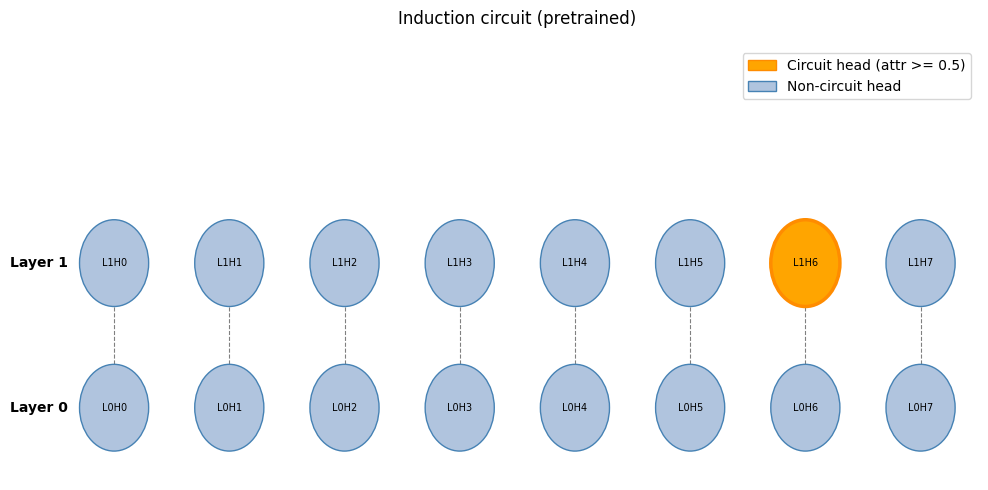

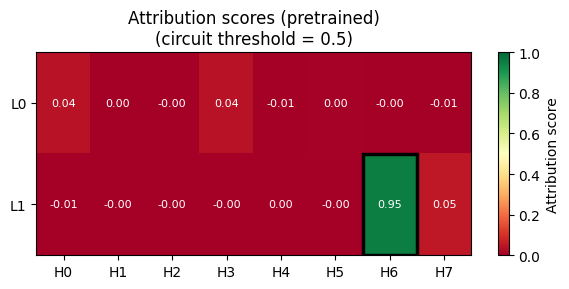

In [5]:
figures_dir = Path('../paper/figures'); figures_dir.mkdir(parents=True, exist_ok=True)
fig1 = plot_circuit_diagram(circuit_heads=circuit_heads, n_layers=model.cfg.n_layers, n_heads=model.cfg.n_heads,
    title='Induction circuit (pretrained)', save_path=figures_dir / 'fig1_circuit_diagram')
plt.show()
fig4 = plot_attribution_heatmap(attribution_scores.cpu().numpy(), threshold=eval_config.induction_circuit_threshold,
    title='Attribution scores (pretrained)', save_path=figures_dir / 'fig4_attribution_baseline')
plt.show()

### Download generated figures

In [6]:
from google.colab import files
import os

# Assuming figures_dir is defined as '../paper/figures' based on previous cells
figures_dir = Path('../paper/figures')

print(f"Files in {figures_dir}:")
for filename in os.listdir(figures_dir):
    print(filename)

# Download the generated figures
print("Downloading fig1_circuit_diagram.png...")
files.download(figures_dir / 'fig1_circuit_diagram.png')

print("Downloading fig4_attribution_baseline.png...")
files.download(figures_dir / 'fig4_attribution_baseline.png')

Files in ../paper/figures:
fig1_circuit_diagram.pdf
fig4_attribution_baseline.png
fig1_circuit_diagram.png
fig4_attribution_baseline.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>